# Convolutional Autoencoders for MNIST Denoising

## Overview
This notebook explores the implementation and comparison of two distinct Convolutional Autoencoder (CAE) architectures for image denoising on the MNIST dataset. The primary goal is to evaluate how different model complexities (number of filters) impact reconstruction quality and, specifically, the ability to remove noise from images.

## Methodology
1.  **Dataset Preparation**: The MNIST dataset is loaded and prepared using PyTorch DataLoaders.
2.  **Model Architectures**: Two CAE configurations (`AutoEncoder_config1` and `AutoEncoder_config2`) are defined:
    *   **`AutoEncoder_config1`**: A more complex model featuring `(8, 14, 14)` and `(4, 7, 7)` dimensional latent representations, with corresponding convolutional layers.
    *   **`AutoEncoder_config2`**: A lighter model with `(4, 14, 14)` and `(2, 7, 7)` dimensional latent representations, using fewer filters in its convolutional layers.
3.  **Training**: Both autoencoders are trained on the MNIST training set for 10 epochs, aiming to minimize reconstruction loss.
4.  **Evaluation**:
    *   Training loss curves are plotted for both models.
    *   Reconstructed images from both models are visualized to qualitatively assess their performance.
5.  **Denoising Challenge**: Gaussian noise is explicitly added to a batch of test images. Both trained autoencoders then attempt to reconstruct these noisy images, and their denoising capabilities are visually compared.

## Key Findings
*   **`AutoEncoder_config1`** achieved a lower training loss (around 0.002), indicating a high fidelity in reconstructing clean images.
*   **`AutoEncoder_config2`**, despite having a slightly higher training loss (around 0.01), demonstrated **superior performance in denoising** the artificially corrupted images.
*   This suggests that a simpler architecture with fewer parameters (as in `AutoEncoder_config2`) might lead to better generalization and a reduced tendency to overfit to noise, allowing it to extract more robust features crucial for effective denoising.

## Imports

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

#### Import utility functions

In [ ]:
from helper_data import get_dataloaders_mnist
from helper_train import train_autoencoder_v1
from helper_utils import set_deterministic, set_all_seeds
from helper_plotting import plot_training_loss
from helper_plotting import plot_generated_images
from helper_plotting import plot_latent_space_with_labels

In [ ]:
##########################
### SETTINGS
##########################

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 10

# Hyperparameters
RANDOM_SEED = 123
LEARNING_RATE = 0.0005
BATCH_SIZE = 32
NUM_EPOCHS = 20

In [ ]:
set_deterministic
set_all_seeds(RANDOM_SEED)

## Dataset

In [ ]:
##########################
### Dataset
##########################

train_loader, valid_loader, test_loader = get_dataloaders_mnist(
    batch_size=BATCH_SIZE,
    num_workers=2,
    validation_fraction=0.)

In [ ]:
# Checking the dataset
print('Training Set:\n')
for images, labels in train_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

# Checking the dataset
print('\nValidation Set:')
for images, labels in valid_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

# Checking the dataset
print('\nTesting Set:')
for images, labels in test_loader:
    print('Image batch dimensions:', images.size())
    print('Image label dimensions:', labels.size())
    print(labels[:10])
    break

Training Set:

Image batch dimensions: torch.Size([32, 1, 28, 28])
Image label dimensions: torch.Size([32])
tensor([1, 2, 1, 9, 0, 6, 9, 8, 0, 1])

Validation Set:

Testing Set:
Image batch dimensions: torch.Size([32, 1, 28, 28])
Image label dimensions: torch.Size([32])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


## Model

In [ ]:
##########################
### MODEL
##########################


class Reshape(nn.Module):
    def __init__(self, *args):
        super().__init__()
        self.shape = args

    def forward(self, x):
        return x.view(self.shape)


class Trim(nn.Module):
    def __init__(self, *args):
        super().__init__()

    def forward(self, x):
        return x[:, :, :28, :28]


class AutoEncoder_config1(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1),   #[8, 14, 14]
            nn.LeakyReLU(0.01),
            nn.Conv2d(8, 4, kernel_size=3, stride=2, padding=1),   #[4, 7, 7]
            nn.LeakyReLU(0.01),
        )

        self.decoder = nn.Sequential(
            Reshape(-1, 4, 7, 7),
            nn.ConvTranspose2d(4, 8, kernel_size=3, stride=2, padding=1, output_padding=1),  #[8, 14, 14]
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(8, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  #[1, 28, 28]
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
set_all_seeds(RANDOM_SEED)

model = AutoEncoder_config1()
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training

In [ ]:
log_dict = train_autoencoder_v1(num_epochs=10, model=model,
                                optimizer=optimizer, device=DEVICE,
                                train_loader=train_loader,
                                skip_epoch_stats=True,
                                logging_interval=250)

Epoch: 001/010 | Batch 0000/1875 | Loss: 0.2307
Epoch: 001/010 | Batch 0250/1875 | Loss: 0.0502
Epoch: 001/010 | Batch 0500/1875 | Loss: 0.0219
Epoch: 001/010 | Batch 0750/1875 | Loss: 0.0117
Epoch: 001/010 | Batch 1000/1875 | Loss: 0.0107
Epoch: 001/010 | Batch 1250/1875 | Loss: 0.0071
Epoch: 001/010 | Batch 1500/1875 | Loss: 0.0069
Epoch: 001/010 | Batch 1750/1875 | Loss: 0.0054
Time elapsed: 0.22 min
Epoch: 002/010 | Batch 0000/1875 | Loss: 0.0050
Epoch: 002/010 | Batch 0250/1875 | Loss: 0.0053
Epoch: 002/010 | Batch 0500/1875 | Loss: 0.0050
Epoch: 002/010 | Batch 0750/1875 | Loss: 0.0048
Epoch: 002/010 | Batch 1000/1875 | Loss: 0.0047
Epoch: 002/010 | Batch 1250/1875 | Loss: 0.0044
Epoch: 002/010 | Batch 1500/1875 | Loss: 0.0036
Epoch: 002/010 | Batch 1750/1875 | Loss: 0.0036
Time elapsed: 0.44 min
Epoch: 003/010 | Batch 0000/1875 | Loss: 0.0040
Epoch: 003/010 | Batch 0250/1875 | Loss: 0.0037
Epoch: 003/010 | Batch 0500/1875 | Loss: 0.0035
Epoch: 003/010 | Batch 0750/1875 | Loss: 0

## Evaluation

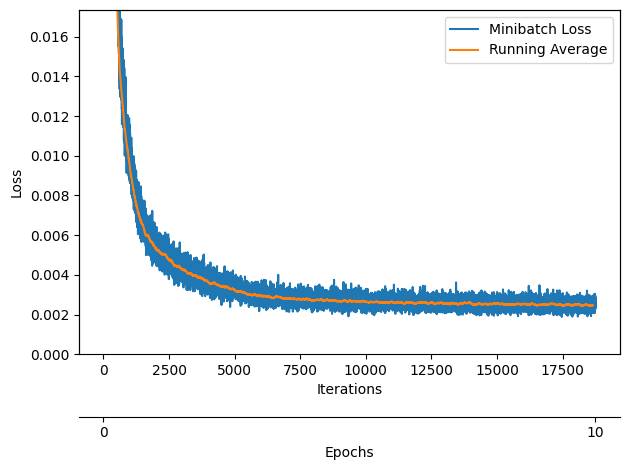

In [ ]:
plot_training_loss(log_dict['train_loss_per_batch'], 10)
plt.show()

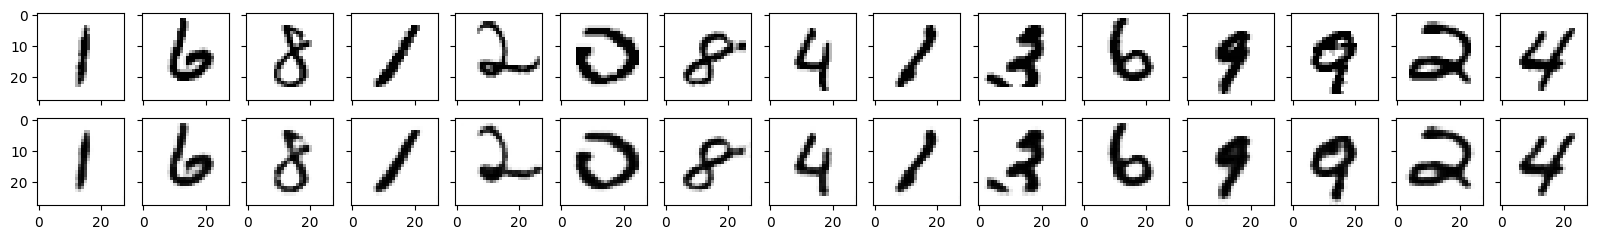

In [ ]:
plot_generated_images(data_loader=train_loader, model=model, device=DEVICE)

Configuration 2


In [ ]:
##########################
### MODEL
##########################

class AutoEncoder_config2(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=3, stride=2, padding=1),   #[4,14,14]
            nn.LeakyReLU(0.01),
            nn.Conv2d(4, 2, kernel_size=3, stride=2, padding=1),   #[2, 7, 7]
            nn.LeakyReLU(0.01),
        )

        self.decoder = nn.Sequential(
            Reshape(-1, 2, 7, 7),
            nn.ConvTranspose2d(2, 4, kernel_size=3, stride=2, padding=1, output_padding=1),  #[4, 14, 14]
            nn.LeakyReLU(0.01),
            nn.ConvTranspose2d(4, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  #[1, 28, 28]
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [ ]:
set_all_seeds(RANDOM_SEED)

model_2 = AutoEncoder_config2()
model_2.to(DEVICE)

optimizer = torch.optim.Adam(model_2.parameters(), lr=LEARNING_RATE)

In [ ]:
log_dict_2 = train_autoencoder_v1(num_epochs=10, model=model_2,
                                optimizer=optimizer, device=DEVICE,
                                train_loader=train_loader,
                                skip_epoch_stats=True,
                                logging_interval=250)

Epoch: 001/010 | Batch 0000/1875 | Loss: 0.2027
Epoch: 001/010 | Batch 0250/1875 | Loss: 0.0898
Epoch: 001/010 | Batch 0500/1875 | Loss: 0.0543
Epoch: 001/010 | Batch 0750/1875 | Loss: 0.0515
Epoch: 001/010 | Batch 1000/1875 | Loss: 0.0447
Epoch: 001/010 | Batch 1250/1875 | Loss: 0.0459
Epoch: 001/010 | Batch 1500/1875 | Loss: 0.0441
Epoch: 001/010 | Batch 1750/1875 | Loss: 0.0408
Time elapsed: 0.22 min


Traceback (most recent call last):
  File "/usr/lib/python3.11/multiprocessing/queues.py", line 239, in _feed
    reader_close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.11/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor


Epoch: 002/010 | Batch 0000/1875 | Loss: 0.0361
Epoch: 002/010 | Batch 0250/1875 | Loss: 0.0328
Epoch: 002/010 | Batch 0500/1875 | Loss: 0.0320
Epoch: 002/010 | Batch 0750/1875 | Loss: 0.0300
Epoch: 002/010 | Batch 1000/1875 | Loss: 0.0274
Epoch: 002/010 | Batch 1250/1875 | Loss: 0.0247
Epoch: 002/010 | Batch 1500/1875 | Loss: 0.0215
Epoch: 002/010 | Batch 1750/1875 | Loss: 0.0193
Time elapsed: 0.44 min
Epoch: 003/010 | Batch 0000/1875 | Loss: 0.0198
Epoch: 003/010 | Batch 0250/1875 | Loss: 0.0193
Epoch: 003/010 | Batch 0500/1875 | Loss: 0.0186
Epoch: 003/010 | Batch 0750/1875 | Loss: 0.0179
Epoch: 003/010 | Batch 1000/1875 | Loss: 0.0167
Epoch: 003/010 | Batch 1250/1875 | Loss: 0.0145
Epoch: 003/010 | Batch 1500/1875 | Loss: 0.0155
Epoch: 003/010 | Batch 1750/1875 | Loss: 0.0152
Time elapsed: 0.66 min
Epoch: 004/010 | Batch 0000/1875 | Loss: 0.0152
Epoch: 004/010 | Batch 0250/1875 | Loss: 0.0153
Epoch: 004/010 | Batch 0500/1875 | Loss: 0.0150
Epoch: 004/010 | Batch 0750/1875 | Loss: 0

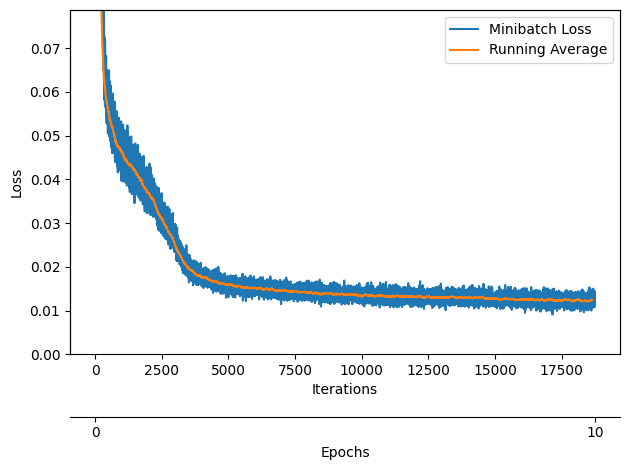

In [ ]:
plot_training_loss(log_dict_2['train_loss_per_batch'], 10)
plt.show()

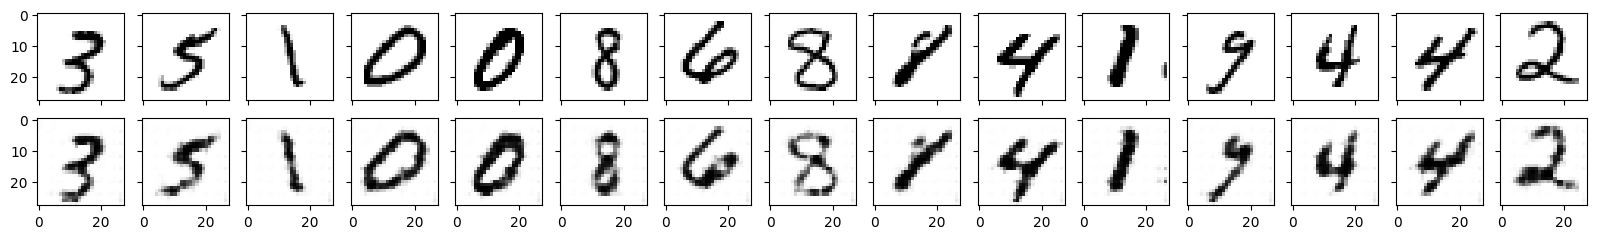

In [ ]:
plot_generated_images(data_loader=train_loader, model=model_2, device=DEVICE)

Testing noisy images with both the model configurations

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def add_noise(images, noise_factor=0.4):
    device = images.device
    noise = noise_factor * torch.randn(*images.shape, device=DEVICE)
    noisy_imgs = images + noise
    noisy_imgs = torch.clamp(noisy_imgs, 0., 1.)  #using torch.clamp instead of np.clip for tensors
    return noisy_imgs


In [ ]:
def visualize(models, test_images, num_samples=10):
    noisy = add_noise(test_images[:num_samples])

    reconstructions = {}
    for name, model in models.items():
        model.eval()
        with torch.no_grad():
            reconstructions[name] = model(noisy)

    #plotting with 4 columns: Original, Noisy, Config 1, Config 2
    fig, axes = plt.subplots(num_samples, 4, figsize=(5, num_samples * 1))

    for i in range(num_samples):
        # Original
        axes[i, 0].imshow(test_images[i][0].cpu(), cmap='gray')
        axes[i, 0].axis('off')
        if i == 0: axes[i, 0].set_title('Original')

        # Noisy
        axes[i, 1].imshow(noisy[i][0].cpu(), cmap='gray')
        axes[i, 1].axis('off')
        if i == 0: axes[i, 1].set_title('Noisy')

        # Config 1 model
        axes[i, 2].imshow(reconstructions['Config 1'][i][0].cpu(), cmap='gray')
        axes[i, 2].axis('off')
        if i == 0: axes[i, 2].set_title('Config 1')

        # Config 2 model
        axes[i, 3].imshow(reconstructions['Config 2'][i][0].cpu(), cmap='gray')
        axes[i, 3].axis('off')
        if i == 0: axes[i, 3].set_title('Config 2')

    plt.tight_layout()
    plt.show()


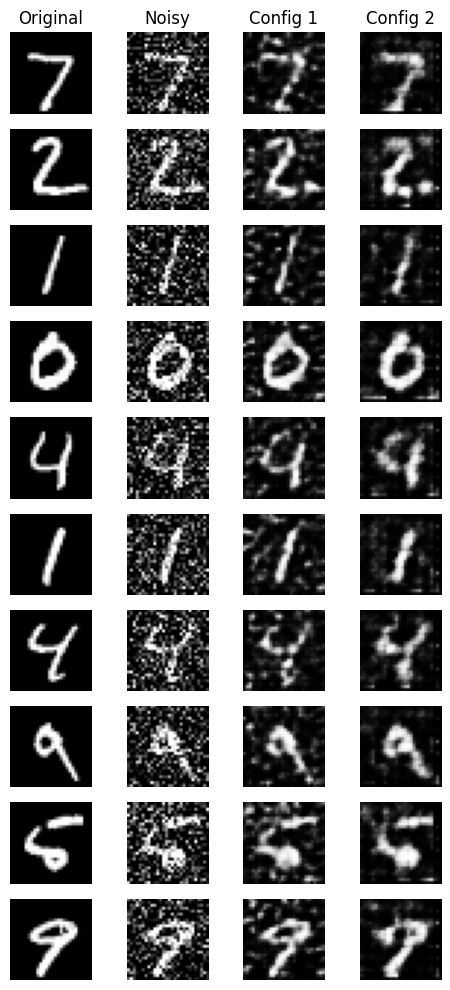

In [ ]:
images, _ = next(iter(test_loader))  #get test batch
images = images.to(DEVICE)

#Dictionary of both models
models_dict = {
    "Config 1": model,
    "Config 2": model_2
}

visualize(models_dict, images, num_samples=10)


**1. Rationale of the first configuration and second configuration**

The first configuration (model) uses 2 convolutional layers using 8 filters followed by 4 filters. The decoder then expands these features back to original input size using transpose convolutional layers with 8 and 1 filter.


The results for this configuration showed that the model was able to achieve a relatively low reconstruction loss of 0.002, indicating good performance in terms of retaining image details.

As the loss was very low, I chose the second model with even lesser parameters, reducing the number of filters.

The second configuration (model_2) uses a lighter architecture, with the encoder consisting of just 4 and 2 filters for the two convolutional layers. This reduces the number of parameters significantly compared to Model 1. It acheives a loss of 0.01.

**2. Does the autoencoder satisfactorily remove noise in the images?**

Although the loss for Model 2 was slightly higher (0.01), it showed superior performance in denoising images. The architecture likely has a better capacity to generalize and remove noise because of the lower number of parameters, which might have helped the model to  focus on key features rather than overfitting.
